# 五分

In [1]:
# %pip install matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import textwrap
from IPython.display import display
from IPython.display import Markdown
from datetime import datetime
import numpy_financial as npf
import math
import pandas as pd
import numpy as np

# 計算 irr

In [3]:
def calculate_irr(signal, threshold):
    # [日期, 評分, 價格]
    hold = 0  # 持有的股數
    balance_in = []  # 每月投入的資金
    balance_total = 0
    month = 1
    this_month_in = 0

    for idx, item in enumerate(signal):
        score = float(item[1])
        price = float(signal[idx][2])
        if score > threshold:
            balance_total += score * 1000  # 買入分數*1000等值的股票
            hold = hold + ((score * 1000) / price)  # 計算持有的股票數

            # 計算每月投入金額
            date_obj = datetime.strptime(item[0], '%Y%m%d')
            if month == date_obj.month:
                this_month_in += score * 1000
            elif month != date_obj.month:
                month = date_obj.month
                this_month_in += score * 1000
                balance_in.append(-this_month_in)
                this_month_in = 0

    balance_in.append(-this_month_in)
    last_price = float(signal[len(signal) - 1][2])
    
    balance_in.append(hold * last_price)
    # print(balance_in)
    irr = npf.irr(balance_in)

    if math.isnan(irr):
        irr = 0

    if balance_total > 0:
        bnh = last_price / float(signal[0][2])
    else:
        bnh = 0

    return round(irr, 5), round(bnh, 5)

In [4]:
def calculate_rtn(signal, threshold):
    # [日期, 評分, 價格]
    hold = 0  # 持有的股數
    retrun = []  # 每月投入的資金
    balance_total = 1000000
    buynhold = []

    for idx, item in enumerate(signal):
        score = float(item[1])
        if idx+1 == len(signal):
            break
        price = float(signal[idx+1][2])
        buynhold.append(price/float(signal[0][2]))

        if score > threshold:
            balance_buy = ((score)/100) * balance_total  # 買入與分數相同百分比的股票
            new_hold = (balance_buy / price)  # 計算持有的股票數
            
            diff = hold - new_hold
            balance_total += diff*price
            hold = new_hold
        
        retrun.append((balance_total + hold*price)/1000000)
        # print(balance_total, hold*price)
    
    balance_total += hold*price

    plt.plot(retrun, label=f'strategy', color='red')
    plt.plot(buynhold, label='buy and hold', color='blue')
    plt.legend()
    plt.show()

    rtn = balance_total/1000000

    if balance_total > 0:
        bnh = float(signal[len(signal)-1][2]) / float(signal[0][2])
    else:
        bnh = 0

    return round(rtn, 5), round(bnh, 5)

# 抓到報酬率

1.0352590000000002
1.036081
1.1285500000000002
1.1575650000000002
1.0231
1.0644380000000002
1.0717830000000002
1.018677
1.11962
1.127034
1.00229
1.061099
1.0538199999999998
1.038993
1.095087
1.0667360000000001
1.1568589999999996
1.0785129999999998
1.066678
1.097266
1.069112
1.049497
1.0539079999999998
1.005041
1.05751
1.04197
1.0986359999999997
1.0706840000000002
0.9658180000000002
1.1356259999999998
1.1138600000000003
1.061679
1.176817
1.083356
1.135925
1.067589
1.047024
1.121252
1.061585
1.0447799999999998
1.0993229999999998
1.093194
1.027777
1.014095
1.121814
1.173562
1.1759560000000002
1.061593
1.08757
1.011652
1.0866649999999998
1.12602
0.994915
1.190583
1.115099
1.0705959999999999
1.094558
1.050466
1.095313
1.072658


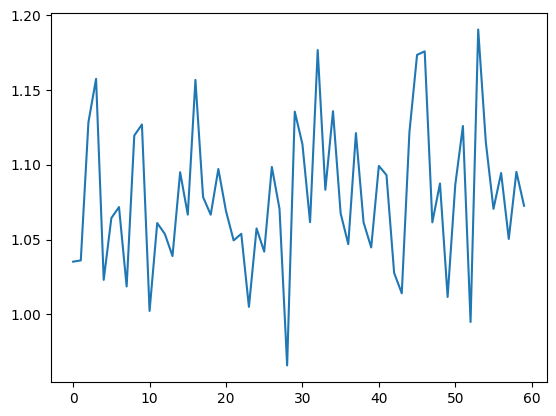

In [54]:
# 20 ~ 51 -100~100
# 88 ~ 137 -100~100
# 157 ~ 235 #非常好(2) #好(1) #無關(0) #不好(-1) #非常不好(-2)

# 20230101 ~ 20231231 一年前5擋股票報酬率 1.405046
# 20230101 ~ 20231231 一年後5擋股票報酬率 1.5045
# 20220101 ~ 20231231 兩年的10擋股票報酬率 1.186132
# 20230101 ~ 20231231 一年的10擋股票報酬率 1.170022

import matplotlib.pyplot as plt
import ast
list_2 = []

for i in range(157, 217):
    acc_list = []
    bnhs = []
    eval_list = []

    with open("eval_gemini/output"+str(i), "r", encoding='utf-8') as f:
        data = f.read()
        list_2.append(float(data.split("平均報酬率:")[1].split("，平均總額投入報")[0])) 
        print(data.split("平均報酬率:")[1].split("，平均總額投入報")[0])
        eval_list = ast.literal_eval(data.split("原始數據")[1])

plt.plot(list_2)

# tp fp 

In [22]:
def eval2(signal, price):
    # [日期, 評分, 價格] , dataframe
    tp = 0
    tn = 0
    fp = 0
    fn = 0

    for idx, item in enumerate(signal):
        score = float(item[1])
        index_location = price.index.get_loc(int(item[0]))  # 獲取特定索引的位置
        if index_location == len(price.index) - 1:
            break
        next_index = price.index[index_location + 1]  # 獲取下一個索引的位置
        next_row = price.loc[next_index]  # 找到下一個索引的行

        if score > 0:
            if next_row['Close'] > next_row['Open']:
                tp += 1
            elif next_row['Close'] == next_row['Open']:
                pass
            else:   
                tn+=1

        if score < 0:
            if next_row['Close'] < next_row['Open']:
                fp += 1
            elif next_row['Close'] == next_row['Open']:
                pass
            else:   
                fn+=1
                
    return tp, tn, fp, fn

In [51]:
# 20 ~ 51 -100~100
# 88 ~ 137 -100~100
# 157 ~ 235 #非常好(2) #好(1) #無關(0) #不好(-1) #非常不好(-2)

# 20230101 ~ 20231231 一年前5擋股票報酬率 1.405046
# 20230101 ~ 20231231 一年後5擋股票報酬率 1.5045
# 20220101 ~ 20231231 兩年的10擋股票報酬率 1.186132
# 20230101 ~ 20231231 一年的10擋股票報酬率 1.170022

import ast


stock_ids = ["1101", "2211", "2385", "2542", "2880", "2912", "3023", "3264", "5269", "8027"]
acc_list = [[], [], [], [], [], [], [], [], [], []]

# 前 20 筆
for i in range(157, 177):
    with open("eval_gemini/output" + str(i), "r", encoding='utf-8') as f:
        data = f.read()
        eval_list = ast.literal_eval(data.split("原始數據")[1])

    increse = 0
    decrese = 0

    for idx, list in enumerate(eval_list):
        dataframe = pd.read_csv(os.path.dirname(os.path.abspath(os.getcwd())) + "/price_history/" + stock_ids[idx] + "price.csv", usecols=['Date', 'Open', 'Close'])
        dataframe.set_index('Date', inplace=True)  # 將'Date'行設置為索引
        tp, tn, fp, fn = eval2(list, dataframe)
        acc_list[idx].append((tp+tn)/(tp+tn+fp+fn))
        # print(f"{stock_ids[idx]} \ttp:{tp}, \ttn:{tn}, \tfp:{fp}, \tfn:{fn}, \tacc:{(tp+tn)/(tp+tn+fp+fn)}")

for idx, acc in enumerate(acc_list):
    print(f"{stock_ids[idx]} 平均準確率:{sum(acc) / len(acc)}")
    # print(f"{stock_ids[idx]} 策略勝利" if sum(acc) / len(acc) > 0.5 else f"{stock_ids[idx]} 策略失敗")
    print("")
    # plt.plot(acc)




1101 平均準確率:0.48365521585829807

2211 平均準確率:0.3354396927461943

2385 平均準確率:0.5099294990072727

2542 平均準確率:0.4618977572490327

2880 平均準確率:0.4031293137853891

2912 平均準確率:0.6069687585728384

3023 平均準確率:0.4946966542161652

3264 平均準確率:0.4348203185703186

5269 平均準確率:0.5222229617568362

8027 平均準確率:0.42670252452861146



In [48]:
acc_list = [[], [], [], [], [], [], [], [], [], []]
# 後 20 筆
for i in range(197, 217):
    with open("eval_gemini/output" + str(i), "r", encoding='utf-8') as f:
        data = f.read()
        eval_list = ast.literal_eval(data.split("原始數據")[1])

    increse = 0
    decrese = 0

    for idx, list in enumerate(eval_list):
        dataframe = pd.read_csv(os.path.dirname(os.path.abspath(os.getcwd())) + "/price_history/" + stock_ids[idx] + "price.csv", usecols=['Date', 'Open', 'Close'])
        dataframe.set_index('Date', inplace=True)  # 將'Date'行設置為索引
        tp, tn, fp, fn = eval2(list, dataframe)
        acc_list[idx].append((tp+tn)/(tp+tn+fp+fn))
        # print(f"{stock_ids[idx]} \ttp:{tp}, \ttn:{tn}, \tfp:{fp}, \tfn:{fn}, \tacc:{(tp+tn)/(tp+tn+fp+fn)}")

for idx, acc in enumerate(acc_list):
    print(f"{stock_ids[idx]} 平均準確率:{sum(acc) / len(acc)}")
    # print(f"{stock_ids[idx]} 策略勝利" if sum(acc) / len(acc) > 0.5 else f"{stock_ids[idx]} 策略失敗")
    print("")
    # plt.plot(acc)

1101 平均準確率:0.5203816436165019

2211 平均準確率:0.41609418767507006

2385 平均準確率:0.5881396886383666

2542 平均準確率:0.511488103849765

2880 平均準確率:0.43813518522677686

2912 平均準確率:0.6562319468121232

3023 平均準確率:0.6461436937581686

3264 平均準確率:0.5065391589404747

5269 平均準確率:0.6162590422003399

8027 平均準確率:0.4638460248314072



1101 平均準確率:0.48365521585829807

2211 平均準確率:0.3354396927461943

2385 平均準確率:0.5099294990072727

2542 平均準確率:0.4618977572490327

2880 平均準確率:0.4031293137853891

2912 平均準確率:0.6069687585728384

3023 平均準確率:0.4946966542161652

3264 平均準確率:0.4348203185703186

5269 平均準確率:0.5222229617568362

8027 平均準確率:0.42670252452861146

==========================================

1101 平均準確率:0.5203816436165019

2211 平均準確率:0.41609418767507006

2385 平均準確率:0.5881396886383666

2542 平均準確率:0.511488103849765

2880 平均準確率:0.43813518522677686

2912 平均準確率:0.6562319468121232

3023 平均準確率:0.6461436937581686

3264 平均準確率:0.5065391589404747

5269 平均準確率:0.6162590422003399

8027 平均準確率:0.4638460248314072